![Itq](img/LogoITQ.jpg)

**Programa 9 - Evaluación Primer Parcial**

![Python](img/python_logo.png)

* *Nombre:* Judith Piedra
* *Fecha :* **30-09-2026**
* *Repositorio:* <a href= "https://github.com/MerakiDevJP/machine2_23092026nocturno.git"> Link del repositorio Github</a>
* https://github.com/MerakiDevJP/machine2_23092026nocturno.git

# Desarrollo de la Evaluación Primer Parcial

1.	Carga y comprensión de los datos — 10 %

* Descarga de base de datos

In [1]:
import kagglehub
import os
import pandas as pd

# 1. Descarga del dataset desde Kaggle 
# https://www.kaggle.com/datasets/mirichoi0218/insurance
path = kagglehub.dataset_download("mirichoi0218/insurance")
print("Ruta de descarga:", path)

# 2. Verificación del contenido del directorio descargado
archivos = os.listdir(path)
print("Archivos disponibles:", archivos)

# 3. Construcción de la ruta absoluta del archivo CSV usando os.path.join
ruta_csv = os.path.join(path, "insurance.csv")

# 4. Carga del archivo en un DataFrame de Pandas
df = pd.read_csv(ruta_csv)
print("\nDataset cargado exitosamente.")

Ruta de descarga: C:\Users\JUDY\.cache\kagglehub\datasets\mirichoi0218\insurance\versions\1
Archivos disponibles: ['insurance.csv']

Dataset cargado exitosamente.


* Comprensión de datos

El conjunto de datos "Medical Cost Personal Dataset" contiene la información de 1,338 individuos con las siguientes variables:

    - Edad: Edad del beneficiario principal.
    - Sexo: Género del asegurado, con categorías "female" (femenino) y "male" (masculino).
    - Índice de Masa Corporal (IMC): Medida que relaciona el peso y la altura del individuo, calculada como peso en kilogramos dividido por la altura en metros al cuadrado.
    - Número de hijos: Cantidad de hijos o dependientes cubiertos por el seguro de salud.
    - Fumador: Estado de fumador del individuo, con categorías "yes" (sí) y "no" (no).
    - Región: Área geográfica de residencia en los Estados Unidos, con categorías "northeast" (noreste), "southeast" (sureste), "southwest" (suroeste) y "northwest" (noroeste).
    - Cargos: Costos médicos individuales facturados por el seguro de salud.

Este conjunto de datos es útil para analizar factores que influyen en los costos de los seguros de salud y desarrollar estrategias de precios dirigidas a diferentes demografías.

In [2]:
# 1. Dimensiones de la tabla de datos (filas/instancias y columnas/atributos)
print(f"Dimensiones del conjunto de datos: {df.shape[0]} filas x {df.shape[1]} columnas\n")

# 2. Visualización de las primeras y últimas instancias
print("--- Primeras 5 filas (head) ---")
display(df.head())

print("\n--- Últimas 5 filas (tail) ---")
display(df.tail())

# 3. Identificación de tipos de datos por columna
print("\n--- Estructura y tipos de datos ---")
df.info()

# 4. Resumen de estadísticos descriptivos iniciales tanto numéricos como categóricos
print("\n--- Estadísticos descriptivos del dataset ---")
display(df.describe(include='all'))

Dimensiones del conjunto de datos: 1338 filas x 7 columnas

--- Primeras 5 filas (head) ---


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



--- Últimas 5 filas (tail) ---


,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603



--- Estructura y tipos de datos ---
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB

--- Estadísticos descriptivos del dataset ---


,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


2.	EDA y calidad de los datos — 15 %

=== VALORES AUSENTES / NULOS POR COLUMNA ===
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Cantidad de registros duplicados detectados: 1
Se han eliminado las filas duplicadas del dataset de trabajo.


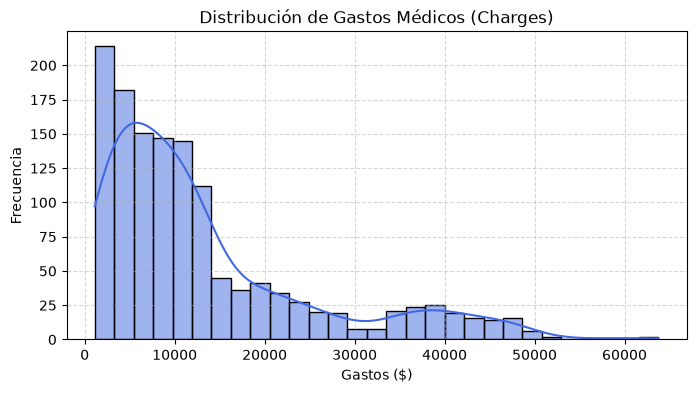

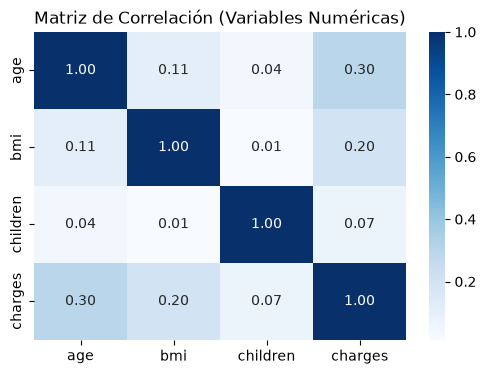

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creación de la copia de trabajo para no alterar el DataFrame original (df)
df_clean = df.copy()

# 2. Verificación de valores ausentes / nulos
print("=== VALORES AUSENTES / NULOS POR COLUMNA ===")
print(df_clean.isna().sum())

# 3. Verificación y tratamiento de registros duplicados
num_duplicados = df_clean.duplicated().sum()
print(f"\nCantidad de registros duplicados detectados: {num_duplicados}")

if num_duplicados > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    print("Se han eliminado las filas duplicadas del dataset de trabajo.")

# 4. Análisis exploratorio visual - Distribución de la variable objetivo (charges)
plt.figure(figsize=(8, 4))
sns.histplot(df_clean['charges'], kde=True, color='royalblue')
plt.title("Distribución de Gastos Médicos (Charges)")
plt.xlabel("Gastos ($)")
plt.ylabel("Frecuencia")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 5. Matriz de correlación lineal entre variables numéricas
plt.figure(figsize=(6, 4))
num_cols = df_clean.select_dtypes(include=['int64', 'float64'])
sns.heatmap(num_cols.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title("Matriz de Correlación (Variables Numéricas)")
plt.show()

3.	Detección de outliers — 10 %

* Diagrama de Cajas - Bigotes

=== METODO 1: DETECCIÓN POR RANGO INTERCUARTÍLICO (IQR) ===
Atributo 'bmi':
  - Límite inferior: 13.67
  - Límite superior: 47.32
  - Cantidad de outliers: 1
Atributo 'charges':
  - Límite inferior: -13120.72
  - Límite superior: 34524.78
  - Cantidad de outliers: 1


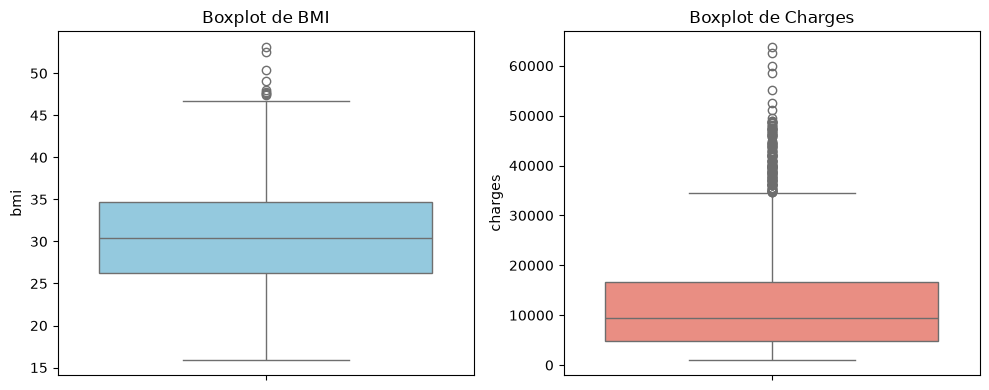

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest

# --- METODO 1: Diagrama de Cajas y Bigotes (IQR) a nivel de atributo ---
print("=== METODO 1: DETECCIÓN POR RANGO INTERCUARTÍLICO (IQR) ===")

# Analizamos las variables continuas numéricas: bmi y charges
cols_num = ['bmi', 'charges']

for col in cols_num:
    a = df_clean[col]
    Q1 = stats.scoreatpercentile(a, 25)
    Q3 = stats.scoreatpercentile(a, 75)
    RIC = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * RIC
    limite_superior = Q3 + 1.5 * RIC
    
    pos_outliers = np.where((a < limite_inferior) | (a > limite_superior))
    
    print(f"Atributo '{col}':")
    print(f"  - Límite inferior: {limite_inferior:.2f}")
    print(f"  - Límite superior: {limite_superior:.2f}")
    print(f"  - Cantidad de outliers: {len(pos_outliers)}")

# Visualización con Diagrama de Caja (Boxplot)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(y=df_clean['bmi'], color='skyblue')
plt.title("Boxplot de BMI")

plt.subplot(1, 2, 2)
sns.boxplot(y=df_clean['charges'], color='salmon')
plt.title("Boxplot de Charges")
plt.tight_layout()
plt.show()

* Isolation Forest


=== METODO 2: ISOLATION FOREST CON GRÁFICO DE DISPERSIÓN ===
Outliers detectados por Isolation Forest: 67


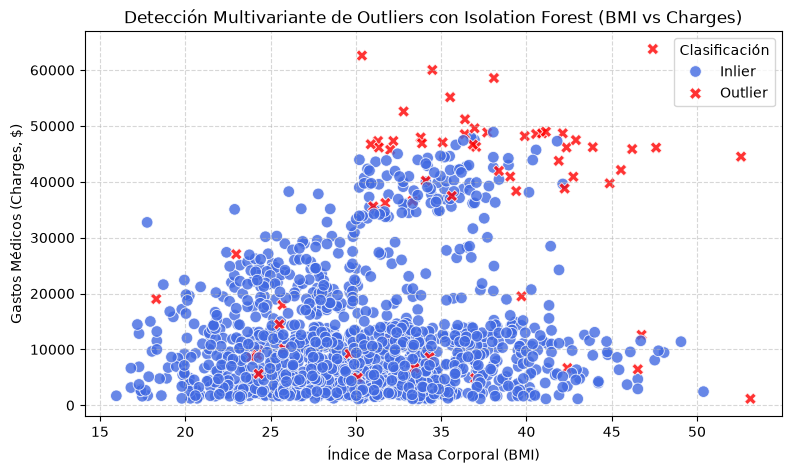

Dimensiones del dataset limpio de outliers: (1270, 7)


In [5]:
# --- METODO 2: Detección Multivariante e Interpretación Visual con Isolation Forest ---
print("\n=== METODO 2: ISOLATION FOREST CON GRÁFICO DE DISPERSIÓN ===")

# 1. Seleccionamos atributos numéricos continuos a nivel de matriz
X_num = df_clean[['age', 'bmi', 'children', 'charges']]

# 2. Entrenamos Isolation Forest con contaminación estimada del 5%
iso = IsolationForest(contamination=0.05, random_state=42)
pred_outliers = iso.fit_predict(X_num)

# 3. Etiquetamos temporalmente las instancias (1 -> Inlier, -1 -> Outlier)
df_clean['outlier_iso'] = np.where(pred_outliers == -1, 'Outlier', 'Inlier')

num_outliers_iso = np.sum(pred_outliers == -1)
print(f"Outliers detectados por Isolation Forest: {num_outliers_iso}")

# 4. GRÁFICO DE DISPERSIÓN (Scatter Plot) de Isolation Forest (BMI vs Charges)
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df_clean, 
    x='bmi', 
    y='charges', 
    hue='outlier_iso', 
    palette={'Inlier': 'royalblue', 'Outlier': 'red'},
    style='outlier_iso',
    markers={'Inlier': 'o', 'Outlier': 'X'},
    s=70,
    alpha=0.8
)
plt.title("Detección Multivariante de Outliers con Isolation Forest (BMI vs Charges)")
plt.xlabel("Índice de Masa Corporal (BMI)")
plt.ylabel("Gastos Médicos (Charges, $)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Clasificación")
plt.show()

# 5. Generamos el DataFrame filtrado reteniendo únicamente las instancias normales (Inliers)
df_sin_outliers = df_clean[df_clean['outlier_iso'] == 'Inlier'].drop(columns=['outlier_iso']).reset_index(drop=True)
df_clean = df_clean.drop(columns=['outlier_iso'])

print(f"Dimensiones del dataset limpio de outliers: {df_sin_outliers.shape}")

4.	Preparación de variables — 10 %

In [6]:
import pandas as pd

# 1. Partimos del DataFrame limpio de outliers (df_sin_outliers)
df_prep = df_sin_outliers.copy()

print("=== ESTADO INICIAL DE VARIABLES CATEGÓRICAS ===")
print(df_prep[['sex', 'smoker', 'region']].head())

# 2. Mapeo directo para variables categóricas binarias (sex, smoker)
df_prep['sex'] = df_prep['sex'].map({'female': 0, 'male': 1})
df_prep['smoker'] = df_prep['smoker'].map({'no': 0, 'yes': 1})

# 3. Codificación One-Hot Encoding para la variable nominal 'region'
# drop_first=True elimina una categoría base para evitar la trampa de variables dummy
df_prep = pd.get_dummies(df_prep, columns=['region'], drop_first=True, dtype=int)

# 4. Verificación del DataFrame preparado
print("\n=== DATAFRAME TRAS LA PREPARACIÓN DE VARIABLES ===")
print(f"Nuevas dimensiones: {df_prep.shape} (filas, columnas)")
print("\nPrimeras 5 filas con todas las variables codificadas a numérico:")
display(df_prep.head())

print("\nVerificación de tipos de datos resultantes:")
print(df_prep.dtypes)

=== ESTADO INICIAL DE VARIABLES CATEGÓRICAS ===
      sex smoker     region
0  female    yes  southwest
1    male     no  southeast
2    male     no  southeast
3    male     no  northwest
4    male     no  northwest

=== DATAFRAME TRAS LA PREPARACIÓN DE VARIABLES ===
Nuevas dimensiones: (1270, 9) (filas, columnas)

Primeras 5 filas con todas las variables codificadas a numérico:


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0



Verificación de tipos de datos resultantes:
age                   int64
sex                   int64
bmi                 float64
children              int64
smoker                int64
charges             float64
region_northwest      int64
region_southeast      int64
region_southwest      int64
dtype: object


5.	Normalización o estandarización — 10 %

* Estandarización con StandardScaler

In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 1. Partimos del DataFrame preparado (df_prep)
df_scaled = df_prep.copy()

# 2. Definimos las variables numéricas continuas que requieren escalado
cols_continuas = ['age', 'bmi', 'children']

# 3. Instanciamos el escalador (StandardScaler de scikit-learn)
scaler = StandardScaler()

# 4. Ajustamos y transformamos únicamente las columnas numéricas de entrada
df_scaled[cols_continuas] = scaler.fit_transform(df_scaled[cols_continuas])

# 5. Verificación de los datos escalados
print("=== DATAFRAME TRAS LA ESTANDARIZACIÓN (StandardScaler) ===")
print("Medias resultantes (deben ser cercanas a 0):")
print(df_scaled[cols_continuas].mean().round(4))

print("\nDesviaciones estándar resultantes (deben ser 1):")
print(df_scaled[cols_continuas].std().round(4))

print("\nPrimeras 5 filas con las variables numéricas estandarizadas:")
display(df_scaled.head())

=== DATAFRAME TRAS LA ESTANDARIZACIÓN (StandardScaler) ===
Medias resultantes (deben ser cercanas a 0):
age        -0.0
bmi         0.0
children    0.0
dtype: float64

Desviaciones estándar resultantes (deben ser 1):
age         1.0004
bmi         1.0004
children    1.0004
dtype: float64

Primeras 5 filas con las variables numéricas estandarizadas:


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,-1.439082,0,-0.422671,-0.921402,1,16884.92400,0,0,1
1,-1.510777,1,0.573710,-0.016390,0,1725.55230,0,1,0
2,-0.793832,1,0.443009,1.793634,0,4449.46200,0,1,0
3,-0.435360,1,-1.304476,-0.921402,0,21984.47061,1,0,0
4,-0.507055,1,-0.256325,-0.921402,0,3866.85520,1,0,0


6.	Selección de atributos — 10 %

=== RANKING DE IMPORTANCIA DE ATRIBUTOS ===


,Atributo,F-Score Original,F-Score Normalizado,Info Mutua Normalizada,p-value
0,smoker,1732.207193,1.000000,0.209020,2.152961e-239
1,age,119.933883,0.069238,1.000000,9.868848e-27
2,bmi,15.277420,0.008820,0.042532,9.772598e-05
3,children,4.666547,0.002694,0.101486,3.094258e-02
4,sex,3.693103,0.002132,0.121674,5.486178e-02
5,region_southwest,2.772597,0.001601,0.001969,9.613753e-02
6,region_southeast,2.530077,0.001461,0.021062,1.119440e-01
7,region_northwest,0.624580,0.000361,0.036452,4.294981e-01


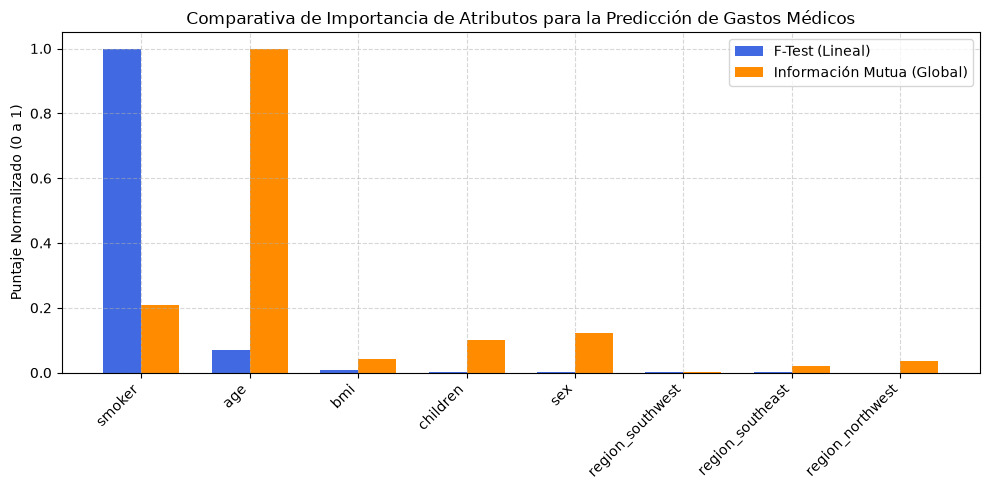

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_regression, mutual_info_regression

# 1. Separación de la matriz de características (X) y el vector objetivo (y)
X = df_scaled.drop(columns=['charges'])
y = df_scaled['charges']

# 2. Evaluación mediante F-Test (relación lineal)
f_scores, p_values = f_regression(X, y)
f_scores_norm = f_scores / np.max(f_scores)  # Normalizado entre 0 y 1

# 3. Evaluación mediante Información Mutua (relaciones lineales y no lineales)
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_scores_norm = mi_scores / np.max(mi_scores)  # Normalizado entre 0 y 1

# 4. Creación de una tabla resumen con el ranking de importancia
df_importancia = pd.DataFrame({
    'Atributo': X.columns,
    'F-Score Original': f_scores,
    'F-Score Normalizado': f_scores_norm,
    'Info Mutua Normalizada': mi_scores_norm,
    'p-value': p_values
}).sort_values(by='F-Score Normalizado', ascending=False).reset_index(drop=True)

print("=== RANKING DE IMPORTANCIA DE ATRIBUTOS ===")
display(df_importancia)

# 5. Visualización comparativa de importancia por atributo
plt.figure(figsize=(10, 5))
x_axis = np.arange(len(X.columns))
width = 0.35

plt.bar(x_axis - width/2, df_importancia['F-Score Normalizado'], width, label='F-Test (Lineal)', color='royalblue')
plt.bar(x_axis + width/2, df_importancia['Info Mutua Normalizada'], width, label='Información Mutua (Global)', color='darkorange')

plt.xticks(x_axis, df_importancia['Atributo'], rotation=45, ha='right')
plt.ylabel("Puntaje Normalizado (0 a 1)")
plt.title("Comparativa de Importancia de Atributos para la Predicción de Gastos Médicos")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

7.	Validación de datos — 10 %

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Separación de la matriz de predictores (X) y el vector objetivo (y)
X = df_scaled.drop(columns=['charges'])
y = df_scaled['charges']

# 2. Partición Hold-Out: 80% Entrenamiento y 20% Prueba (Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 3. Verificación corregida de dimensiones
print("=== DIVISIÓN DE DATOS (HOLD-OUT VALIDATION) ===")
print(f"Dimensiones X_train (Entrenamiento): {X_train.shape[0]} instancias x {X_train.shape[1]} atributos")
print(f"Dimensiones X_test (Prueba/Test):   {X_test.shape[0]} instancias x {X_test.shape[1]} atributos")
print(f"Instancias y_train (Objetivo Train): {y_train.shape[0]}")
print(f"Instancias y_test (Objetivo Test):   {y_test.shape[0]}")

=== DIVISIÓN DE DATOS (HOLD-OUT VALIDATION) ===
Dimensiones X_train (Entrenamiento): 1016 instancias x 8 atributos
Dimensiones X_test (Prueba/Test):   254 instancias x 8 atributos
Instancias y_train (Objetivo Train): 1016
Instancias y_test (Objetivo Test):   254


8.	Entrenamiento mediante Regresión Lineal — 10 %

In [10]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Instanciación del algoritmo de aprendizaje OLS
modelo_reg = LinearRegression(fit_intercept=True)

# 2. Ajuste / Entrenamiento del modelo sobre los datos de entrenamiento (X_train, y_train)
modelo_reg.fit(X_train, y_train)

# 3. Extracción de los parámetros aprendidos
intercepto = modelo_reg.intercept_
coeficientes = modelo_reg.coef_

print("=== ENTRENAMIENTO DEL MODELO DE REGRESIÓN LINEAL MÚLTIPLE ===")
print(f"Término Independiente / Intercepto (w0): {intercepto:.4f}\n")

# 4. Presentación tabular de los coeficientes asignados a cada atributo
df_coeficientes = pd.DataFrame({
    'Atributo': X_train.columns,
    'Coeficiente (w_i)': coeficientes,
    'Efecto Absoluto': np.abs(coeficientes)
}).sort_values(by='Efecto Absoluto', ascending=False).reset_index(drop=True)

print("=== COEFICIENTES DEL MODELO APRENDIDOS (PESOS) ===")
display(df_coeficientes[['Atributo', 'Coeficiente (w_i)']])

=== ENTRENAMIENTO DEL MODELO DE REGRESIÓN LINEAL MÚLTIPLE ===
Término Independiente / Intercepto (w0): 8529.9416

=== COEFICIENTES DEL MODELO APRENDIDOS (PESOS) ===


,Atributo,Coeficiente (w_i)
0,smoker,21589.966946
1,age,3549.293501
2,bmi,1567.317964
3,region_southeast,-783.739620
4,region_southwest,-682.169733
5,children,404.390150
6,sex,241.819948
7,region_northwest,-37.457248


9.	Evaluación — 10 %

=== MÉTRICAS DE EVALUACIÓN DEL MODELO EN EL CONJUNTO DE PRUEBA ===
MAE  (Error Absoluto Medio):              $3603.54
MSE  (Error Cuadrático Medio):             $30011456.68
RMSE (Raíz del Error Cuadrático Medio):    $5478.27
MAPE (Error Porcentual Absoluto Medio):   37.94%
R²   (Coeficiente de Determinación):      0.7134



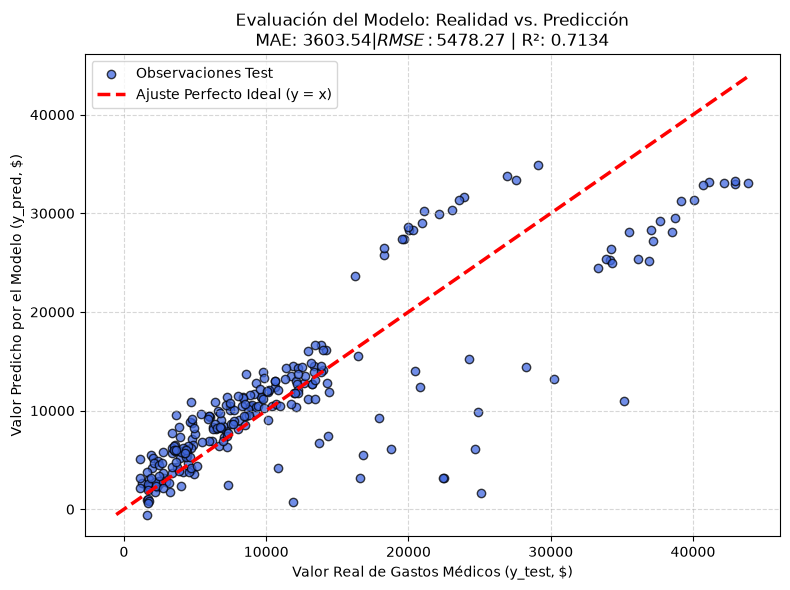

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics

# 1. Inferencia / Predicción sobre el conjunto de prueba (X_test)
y_pred = modelo_reg.predict(X_test)

# 2. Cálculo de métricas de evaluación
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = metrics.mean_absolute_percentage_error(y_test, y_pred) * 100
r2 = metrics.r2_score(y_test, y_pred)

print("=== MÉTRICAS DE EVALUACIÓN DEL MODELO EN EL CONJUNTO DE PRUEBA ===")
print(f"MAE  (Error Absoluto Medio):              ${mae:.2f}")
print(f"MSE  (Error Cuadrático Medio):             ${mse:.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio):    ${rmse:.2f}")
print(f"MAPE (Error Porcentual Absoluto Medio):   {mape:.2f}%")
print(f"R²   (Coeficiente de Determinación):      {r2:.4f}\n")

# 3. Gráfica de Realidad vs. Predicción (Valores Reales vs. Estimados)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='royalblue', edgecolors='black', alpha=0.75, label='Observaciones Test')

# Línea de referencia ideal de predicción perfecta (y_test = y_pred)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', lw=2.5, label='Ajuste Perfecto Ideal (y = x)')

plt.title(f"Evaluación del Modelo: Realidad vs. Predicción\nMAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R²: {r2:.4f}")
plt.xlabel("Valor Real de Gastos Médicos (y_test, $)")
plt.ylabel("Valor Predicho por el Modelo (y_pred, $)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

10.	Predicción con nuevos datos — 5 %

In [12]:
import pandas as pd
import numpy as np

# 1. Definición de la información del nuevo paciente (datos crudos)
nuevo_paciente = pd.DataFrame([{
    'age': 35,
    'sex': 'female',
    'bmi': 28.5,
    'children': 2,
    'smoker': 'yes',
    'region': 'southeast'
}])

print("=== DATOS CRUDOS DEL NUEVO PACIENTE ===")
display(nuevo_paciente)

# 2. Aplicación de transformaciones (Pipeline de Preprocesamiento)
df_nuevo_prep = nuevo_paciente.copy()

# A. Mapeo directo de variables binarias
df_nuevo_prep['sex'] = df_nuevo_prep['sex'].map({'female': 0, 'male': 1})
df_nuevo_prep['smoker'] = df_nuevo_prep['smoker'].map({'no': 0, 'yes': 1})

# B. Construcción de variables One-Hot Encoding para 'region'
regiones_dummy = ['region_northwest', 'region_southeast', 'region_southwest']
for reg_col in regiones_dummy:
    nombre_region = reg_col.replace('region_', '')
    df_nuevo_prep[reg_col] = 1 if nuevo_paciente['region'].values[0] == nombre_region else 0

df_nuevo_prep = df_nuevo_prep.drop(columns=['region'])

# C. Escalado de variables continuas utilizando el StandardScaler ajustado previo
cols_continuas = ['age', 'bmi', 'children']
df_nuevo_prep[cols_continuas] = scaler.transform(df_nuevo_prep[cols_continuas])

# D. Reordenamiento de columnas para coincidir exactamente con la matriz X_train
df_nuevo_prep = df_nuevo_prep[X.columns]

print("\n=== INSTANCIA PREPARADA Y ESCALADA ===")
display(df_nuevo_prep)

# 3. Inferencia / Predicción del gasto médico con el modelo entrenado
prediccion_charges = modelo_reg.predict(df_nuevo_prep)[0]

print(f"\n========================================================")
print(f" GASTO MÉDICO ESTIMADO (CHARGES): ${prediccion_charges:.2f}")
print(f"========================================================\n")

=== DATOS CRUDOS DEL NUEVO PACIENTE ===


,age,sex,bmi,children,smoker,region
0,35,female,28.5,2,yes,southeast



=== INSTANCIA PREPARADA Y ESCALADA ===


,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,-0.291971,0,-0.320826,0.888622,1,0,1,0



 GASTO MÉDICO ESTIMADO (CHARGES): $28156.39

